<a href="https://colab.research.google.com/github/ibel123/OIBSIP/blob/main/DataScience-Task2-Salesprediction/Sales_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales Prediction Using Python

Oasis Infobyte SIP, Data Science Track, Task 5

This notebook builds a model that predicts product sales based on how much money was spent on advertising across three channels: TV, Radio, and Newspaper.

We will follow these steps:
1. Load the dataset
2. Explore the data (EDA)
3. Visualize relationships between spend and sales
4. Check correlation between variables
5. Split the data into training and testing sets
6. Train a baseline Linear Regression model
7. Train a second model for comparison
8. Evaluate both models
9. Look at the residuals
10. Interpret which advertising channel matters most


## Step 1: Import the libraries we need

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set(style="whitegrid")


## Step 2: Load the dataset

This dataset is not built into any library. You need to upload the file `Advertising.csv` yourself.

Run the cell below. It will show an upload button. Click it, then choose the `Advertising.csv` file from your computer.

In [32]:
from google.colab import files

uploaded = files.upload()


Saving Advertising.csv to Advertising (2).csv


In [33]:
df = pd.read_csv("Advertising.csv")

# Some versions of this dataset include an extra unnamed index column, we drop it if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

df.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Step 3: Explore the data

We check the shape, look for missing values, and look at basic statistics before doing anything else.

In [34]:
print("Shape of the dataset (rows, columns):", df.shape)


Shape of the dataset (rows, columns): (200, 4)


In [35]:
print("Checking for missing values:")
df.isnull().sum()


Checking for missing values:


,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [36]:
print("Descriptive statistics:")
df.describe()


Descriptive statistics:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


The dataset has 200 rows, one row per product or market, with spend amounts for TV, Radio, and Newspaper advertising, and the resulting Sales figure. There are no missing values.

## Step 4: Visualize the data

First a pairplot to see every variable against every other variable at once, then individual scatter plots for each advertising channel against Sales.

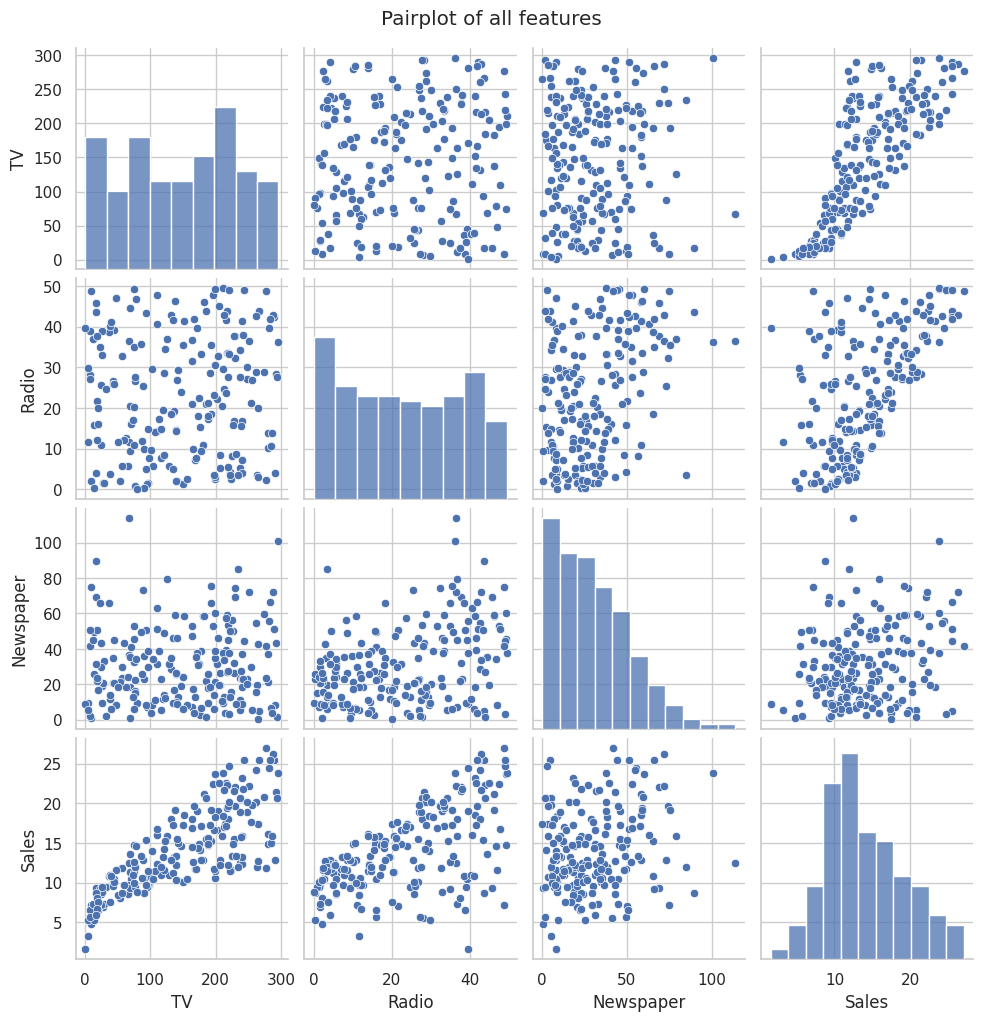

In [37]:
sns.pairplot(df)
plt.suptitle("Pairplot of all features", y=1.02)
plt.show()


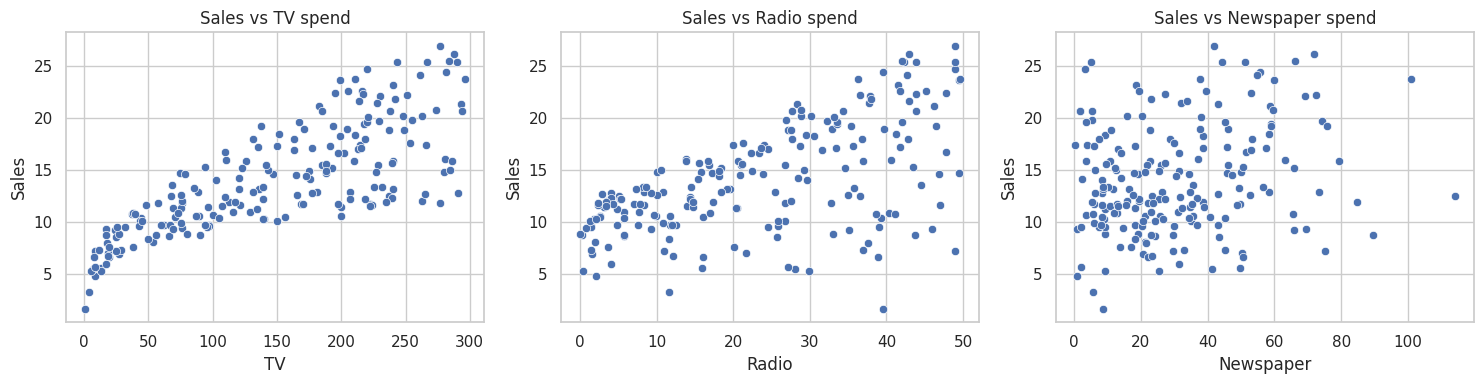

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.scatterplot(data=df, x="TV", y="Sales", ax=axes[0])
axes[0].set_title("Sales vs TV spend")

sns.scatterplot(data=df, x="Radio", y="Sales", ax=axes[1])
axes[1].set_title("Sales vs Radio spend")

sns.scatterplot(data=df, x="Newspaper", y="Sales", ax=axes[2])
axes[2].set_title("Sales vs Newspaper spend")

plt.tight_layout()
plt.show()


TV spend usually shows the clearest upward trend with Sales. Radio also shows a positive trend, though a bit noisier. Newspaper spend tends to show the weakest and noisiest relationship with Sales.

## Step 5: Correlation matrix

A heatmap of correlations gives us a single number for how strongly each pair of variables moves together, from minus 1 to plus 1.

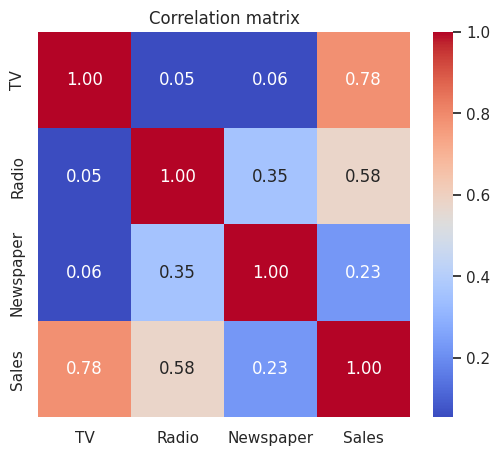

In [39]:
plt.figure(figsize=(6, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()


The correlation between each channel and Sales tells us, roughly, how strongly that channel moves together with Sales. A value close to 1 means a strong positive relationship. A value close to 0 means little to no relationship. TV has the highest correlation with Sales, Newspaper the lowest.

## Step 6: Split the data into training and testing sets

We train on 80 percent of the data and test on the remaining 20 percent to see how well the model performs on data it has not seen before.

In [40]:
X = df[["TV", "Radio", "Newspaper"]]
y = df["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 160
Testing samples: 40


## Step 7: Train the models

We train two models:
1. Linear Regression, our baseline. It assumes Sales is a straight line combination of the three advertising channels
2. Random Forest Regressor, a more flexible model that can capture more complicated, non-linear patterns

In [41]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_reg_preds = lin_reg.predict(X_test)


In [42]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_train)

rf_preds = rf_reg.predict(X_test)


## Step 8: Evaluate both models

For regression problems (predicting a number rather than a category) we use measures:

1. MAE, Mean Absolute Error, the average size of the mistake, in the same units as Sales
2. RMSE, Root Mean Squared Error, similar to MAE but punishes big mistakes more heavily
3. R squared, a score from 0 to 1 showing how much of the variation in Sales the model explains. Closer to 1 is better.

In [43]:
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}")
    print(f"  MAE:  {mae:.3f}")
    print(f"  RMSE: {rmse:.3f}")
    print(f"  R2:   {r2:.3f}")
    print()

evaluate("Linear Regression", y_test, lin_reg_preds)
evaluate("Random Forest Regressor", y_test, rf_preds)


Linear Regression
  MAE:  1.461
  RMSE: 1.782
  R2:   0.899

Random Forest Regressor
  MAE:  0.629
  RMSE: 0.757
  R2:   0.982



## Step 9: Residual plot

A residual is the difference between the actual Sales value and what the model predicted. If a model is doing well, its residuals should be scattered randomly around zero, with no obvious pattern. If there is a clear pattern, that means the model is systematically getting something wrong.

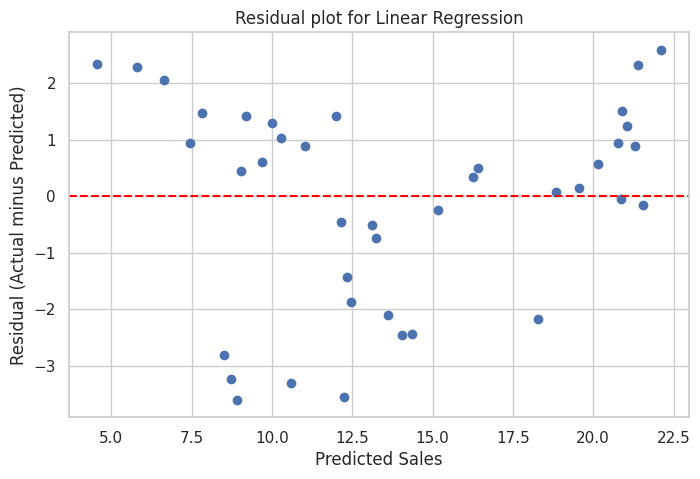

In [44]:
residuals = y_test - lin_reg_preds

plt.figure(figsize=(8, 5))
plt.scatter(lin_reg_preds, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual minus Predicted)")
plt.title("Residual plot for Linear Regression")
plt.show()


The Linear Regression model fits the data reasonably well because the dots are scattered randomly above and below the red line with no funnel shape or curve, . A clear curve or widening spread would suggest a straight line model is not capturing the full pattern.

## Step 10: Which advertising channel has the highest impact on sales?

For Linear Regression, we can look directly at the coefficients. Each coefficient tells us how much Sales is expected to increase for every one unit increase in that channel's spend, holding the other channels constant.

In [45]:
coefficients = pd.DataFrame({
    "Channel": X.columns,
    "Coefficient": lin_reg.coef_
}).sort_values(by="Coefficient", ascending=False)

coefficients


,Channel,Coefficient
1,Radio,0.189195
0,TV,0.044730
2,Newspaper,0.002761


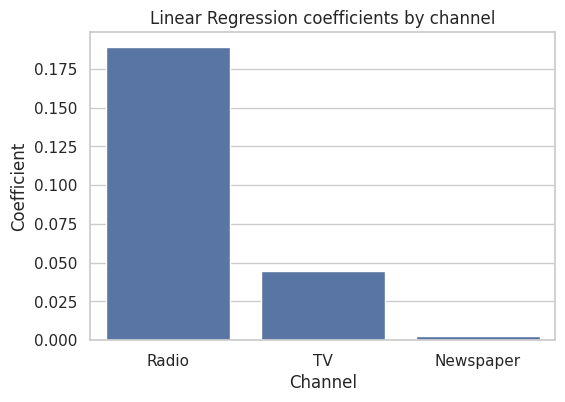

In [46]:
plt.figure(figsize=(6, 4))
sns.barplot(data=coefficients, x="Channel", y="Coefficient")
plt.title("Linear Regression coefficients by channel")
plt.show()


Radio is the channel with the largest coefficient which means it has the biggest effect on Sales for each extra unit of spend. While Newspaper's coefficient is small and close to zero, meaning newspaper spend barely moves Sales at all once TV and Radio are accounted for.

We can also check feature importance from the Random Forest model, which measures how much each feature helped the model make accurate splits.

In [47]:
importances = pd.DataFrame({
    "Channel": X.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values(by="Importance", ascending=False)

importances


,Channel,Importance
0,TV,0.624727
1,Radio,0.362119
2,Newspaper,0.013153


## Conclusion

Both models performed well, with the Random Forest Regressor achieving a lower RMSE and higher R squared than Linear Regression, suggesting a slightly non straight line relationship between spend and Sales. Looking at both the Linear Regression coefficients and the Random Forest feature importances, TV spend has the strongest impact on Sales, followed by Radio. Newspaper spend has almost no measurable impact once TV and Radio are accounted for. This suggests that if a company wants to grow sales, its advertising budget is best spent on TV and Radio, not Newspaper.
